# 06_analisis_exploratorio

Proyecto ARIMA / ARIMAX
Modelación epidemiológica con variables meteorológicas.

# Inicio del análisis


Para esta **etapa de análisis exploratorio (EDA)** en el estudio del comportamiento del dengue en Caucasia con relación a variables meteorológicas, seguiremos una estructura de un **mini–diagnóstico epidemiológico y climático de la serie temporal**. 




# 1. Verificación estructural de la base

Primero asegúrate de que la serie es consistente.

Objetivos:

* Semanas consecutivas
* Sin duplicados
* Sin huecos


# Lectura y conversión a dataframe de el dataset fusionado 

In [2]:
import pandas as pd 

path_janis = r"C:\Users\usuario1\Documents\GitHub\arima\1_programa_trabajo\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\03_fusionados_y_limpieza_datos\datos_fusionados_semanales.xlsx"
df_fusionado = pd.read_excel(path_janis)
# hacer que fecha sea el indice y sea de tipo datetime
df_fusionado['fecha'] = pd.to_datetime(df_fusionado['fecha'])
df_fusionado.set_index('fecha', inplace=True) 
df_fusionado.head()

,año,semana_epidemiologica,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv
fecha,,,,,,,,,,,,,,
2021-01-02,2020,53,0,28.252857,34.200000,23.832857,16.308571,70.508571,5.72,1,0.121429,0.244286,0.047143,2.222857
2021-01-09,2021,1,0,28.687143,34.910000,24.195714,17.318571,72.885714,19.15,5,0.117143,0.208571,0.038571,2.254286
2021-01-16,2021,2,0,29.592857,36.372857,24.090000,16.112857,65.122857,0.77,0,0.124286,0.225714,0.045714,2.420000
2021-01-23,2021,3,0,29.190000,35.978571,24.200000,16.511429,68.068571,12.92,4,0.122857,0.220000,0.035714,2.477143
2021-01-30,2021,4,0,29.454286,35.882857,24.684286,17.427143,70.105714,17.94,3,0.120000,0.221429,0.030000,2.290000


# Visualización tabular 

In [3]:
df_fusionado.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 262 entries, 2021-01-02 to 2026-01-03
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   año                    262 non-null    int64  
 1   semana_epidemiologica  262 non-null    int64  
 2   casos_dengue           262 non-null    int64  
 3   temp                   262 non-null    float64
 4   temp_max               262 non-null    float64
 5   temp_min               262 non-null    float64
 6   hum_esp                262 non-null    float64
 7   hum_rel                262 non-null    float64
 8   prec                   262 non-null    float64
 9   dias_lluvia            262 non-null    int64  
 10  vel_vi                 262 non-null    float64
 11  vel_vi_max             262 non-null    float64
 12  vel_vi_min             262 non-null    float64
 13  uv                     262 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 

# Tarea: redactar la interpretación de esta tabla para el trabajo de grado y el artículo 

In [4]:
df_fusionado.describe().round(1)



,año,semana_epidemiologica,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv
count,262.0,262.0,262.0,262.0,262.0,262.0,262.0,262.0,262.0,262.0,262.0,262.0,262.0,262.0
mean,2023.0,26.5,23.3,27.4,31.4,24.4,18.7,83.1,32.3,4.3,0.1,0.3,0.0,1.2
std,1.4,15.2,23.4,1.5,2.8,0.8,1.5,10.5,28.4,2.4,0.0,0.1,0.0,15.5
min,2020.0,1.0,0.0,25.1,27.6,21.8,15.0,55.9,0.0,0.0,0.1,0.2,0.0,-248.4
25%,2022.0,13.2,7.0,26.2,29.1,23.8,17.5,74.6,11.3,2.0,0.1,0.3,0.0,2.0
50%,2023.0,26.5,16.0,27.0,30.2,24.4,19.1,88.8,26.7,5.0,0.1,0.3,0.0,2.2
75%,2024.0,39.8,34.0,28.3,33.5,24.9,19.9,91.5,44.6,6.0,0.2,0.4,0.0,2.3
max,2026.0,53.0,118.0,32.7,39.0,27.7,21.1,94.1,160.4,7.0,0.2,0.5,0.1,2.7


# Tarea: redactar la interpretación de esta tabla para el trabajo de grado y el artículo 


# Verificar continuidad temporal:




Revisar faltantes:



In [5]:
df_fusionado.isna().sum()


año                      0
semana_epidemiologica    0
casos_dengue             0
temp                     0
temp_max                 0
temp_min                 0
hum_esp                  0
hum_rel                  0
prec                     0
dias_lluvia              0
vel_vi                   0
vel_vi_max               0
vel_vi_min               0
uv                       0
dtype: int64


# 2. Evolución temporal de los casos de dengue

Esto permite ver:

* brotes
* estacionalidad
* tendencias



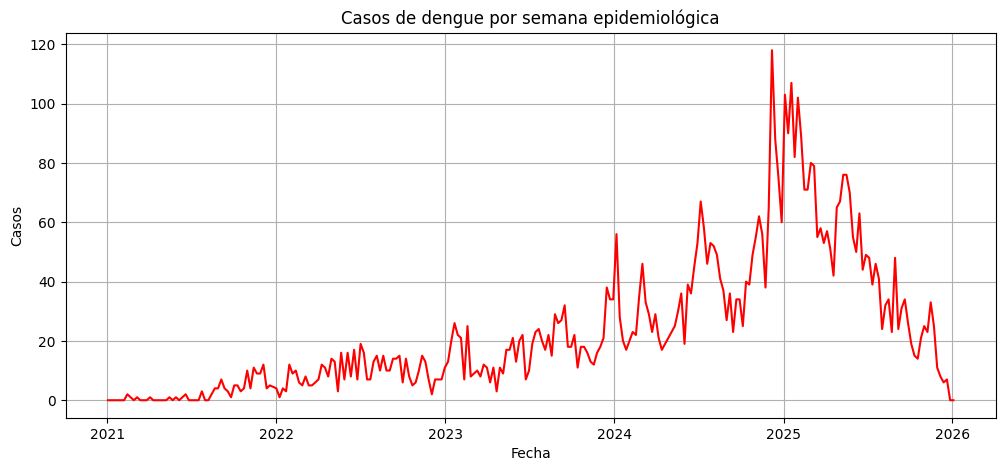

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df_fusionado.index, df_fusionado["casos_dengue"], color="red", marker="", linestyle="-")

plt.title("Casos de dengue por semana epidemiológica")
plt.xlabel("Fecha")
plt.ylabel("Casos")
plt.grid()
plt.savefig("casos_dengue.png")
plt.show()



## 1. Tendencia temporal creciente 

El gráfico evidencia una **tendencia creciente clara en el número de casos a lo largo del tiempo (2021–2024)**.

* En **2021**, los casos se mantienen en niveles muy bajos (cercanos a 0–5 casos por semana).
* Durante **2022**, comienza a observarse un incremento gradual (alrededor de 5–20 casos semanales).
* En **2023**, los casos muestran un aumento más marcado, con valores que oscilan entre **10 y 50 casos**.
* En **2024**, se presenta un **crecimiento notable**, alcanzando picos cercanos a **140 casos semanales**.



## **Interpretación epidemiológica:**
Este patrón puede reflejar:

* aumento en la transmisión del virus,
* condiciones climáticas favorables para el vector,
* acumulación de población susceptible,
* o mejoras en el sistema de vigilancia epidemiológica.

## **Interpretación para modelación:**
La presencia de una tendencia indica que la serie **no es estacionaria en media**, lo cual es una condición importante para aplicar modelos de la familia ARIMA.
Por tanto, **probablemente será necesario aplicar diferenciación ($d \geq 1$)** para estabilizar la serie.

---



## 2. Incremento de la variabilidad (heterocedasticidad visual)

Se observa que **la amplitud de las fluctuaciones aumenta con el tiempo**:

* En los primeros años las variaciones son pequeñas.
* En los últimos años las oscilaciones son más amplias.

Esto sugiere:

* posible **varianza no constante**,
* o **dinámica epidémica creciente**.

En modelación de series temporales esto puede motivar considerar:

* transformaciones como
  $$
  y_t' = \log(y_t + 1)
  $$
* o transformaciones de Box-Cox antes del ajuste del modelo.

---



## 3. Presencia de picos epidémicos 

Se identifican **picos pronunciados en 2024**, con valores cercanos a:

* 90 casos
* 100 casos
* más de **140 casos semanales**

Estos picos pueden representar:

* **brotes epidémicos locales**
* cambios abruptos en las condiciones climáticas
* expansión del vector *Aedes aegypti*.

Desde el punto de vista del sistema de alerta temprana, estos picos son **eventos críticos que el modelo debe anticipar**.

---



## 4. Posible estacionalidad 

Aunque el gráfico no permite confirmar completamente el patrón, se observa que los picos parecen repetirse **en ciertos periodos del año**, lo cual sugiere **posible estacionalidad anual**.

Esto es coherente con la epidemiología del Dengue, ya que la transmisión suele depender de variables climáticas como:

* temperatura
* precipitación
* humedad relativa

En este caso, podría evaluarse un modelo:

* **Seasonal ARIMA (SARIMA)**
  con periodo estacional:

$$
s = 52
$$

(semanas epidemiológicas).

---



## 5. Posible valor atípico al final de la serie

El último punto muestra una **caída abrupta a casi cero casos**.

Esto probablemente **no corresponde a un fenómeno epidemiológico real**, sino a:

* semana epidemiológica incompleta
* retraso en el reporte
* corte de la base de datos

Por lo tanto, este punto debe:

* eliminarse,
* imputarse,
* o marcarse como **dato censurado** antes de ajustar el modelo.

---



# Conclusión para el proceso de modelación

El análisis exploratorio sugiere que la serie presenta:

1. **Tendencia creciente**
2. **Incremento en la variabilidad**
3. **Picos epidémicos**
4. **Posible estacionalidad anual**
5. **Un dato atípico al final de la serie**

En consecuencia, para la construcción del modelo de pronóstico dentro del sistema de alerta temprana se recomienda:

1. verificar estacionariedad (ADF o KPSS),
2. aplicar diferenciación,
3. evaluar transformaciones logarítmicas,
4. analizar funciones **ACF y PACF**,
5. probar modelos:

   * ARIMA
   * Seasonal ARIMA.

---



# 3. Comportamiento de las variables climáticas



In [7]:
df_fusionado.columns 

Index(['año', 'semana_epidemiologica', 'casos_dengue', 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'vel_vi_max', 'vel_vi_min', 'uv'],
      dtype='object')

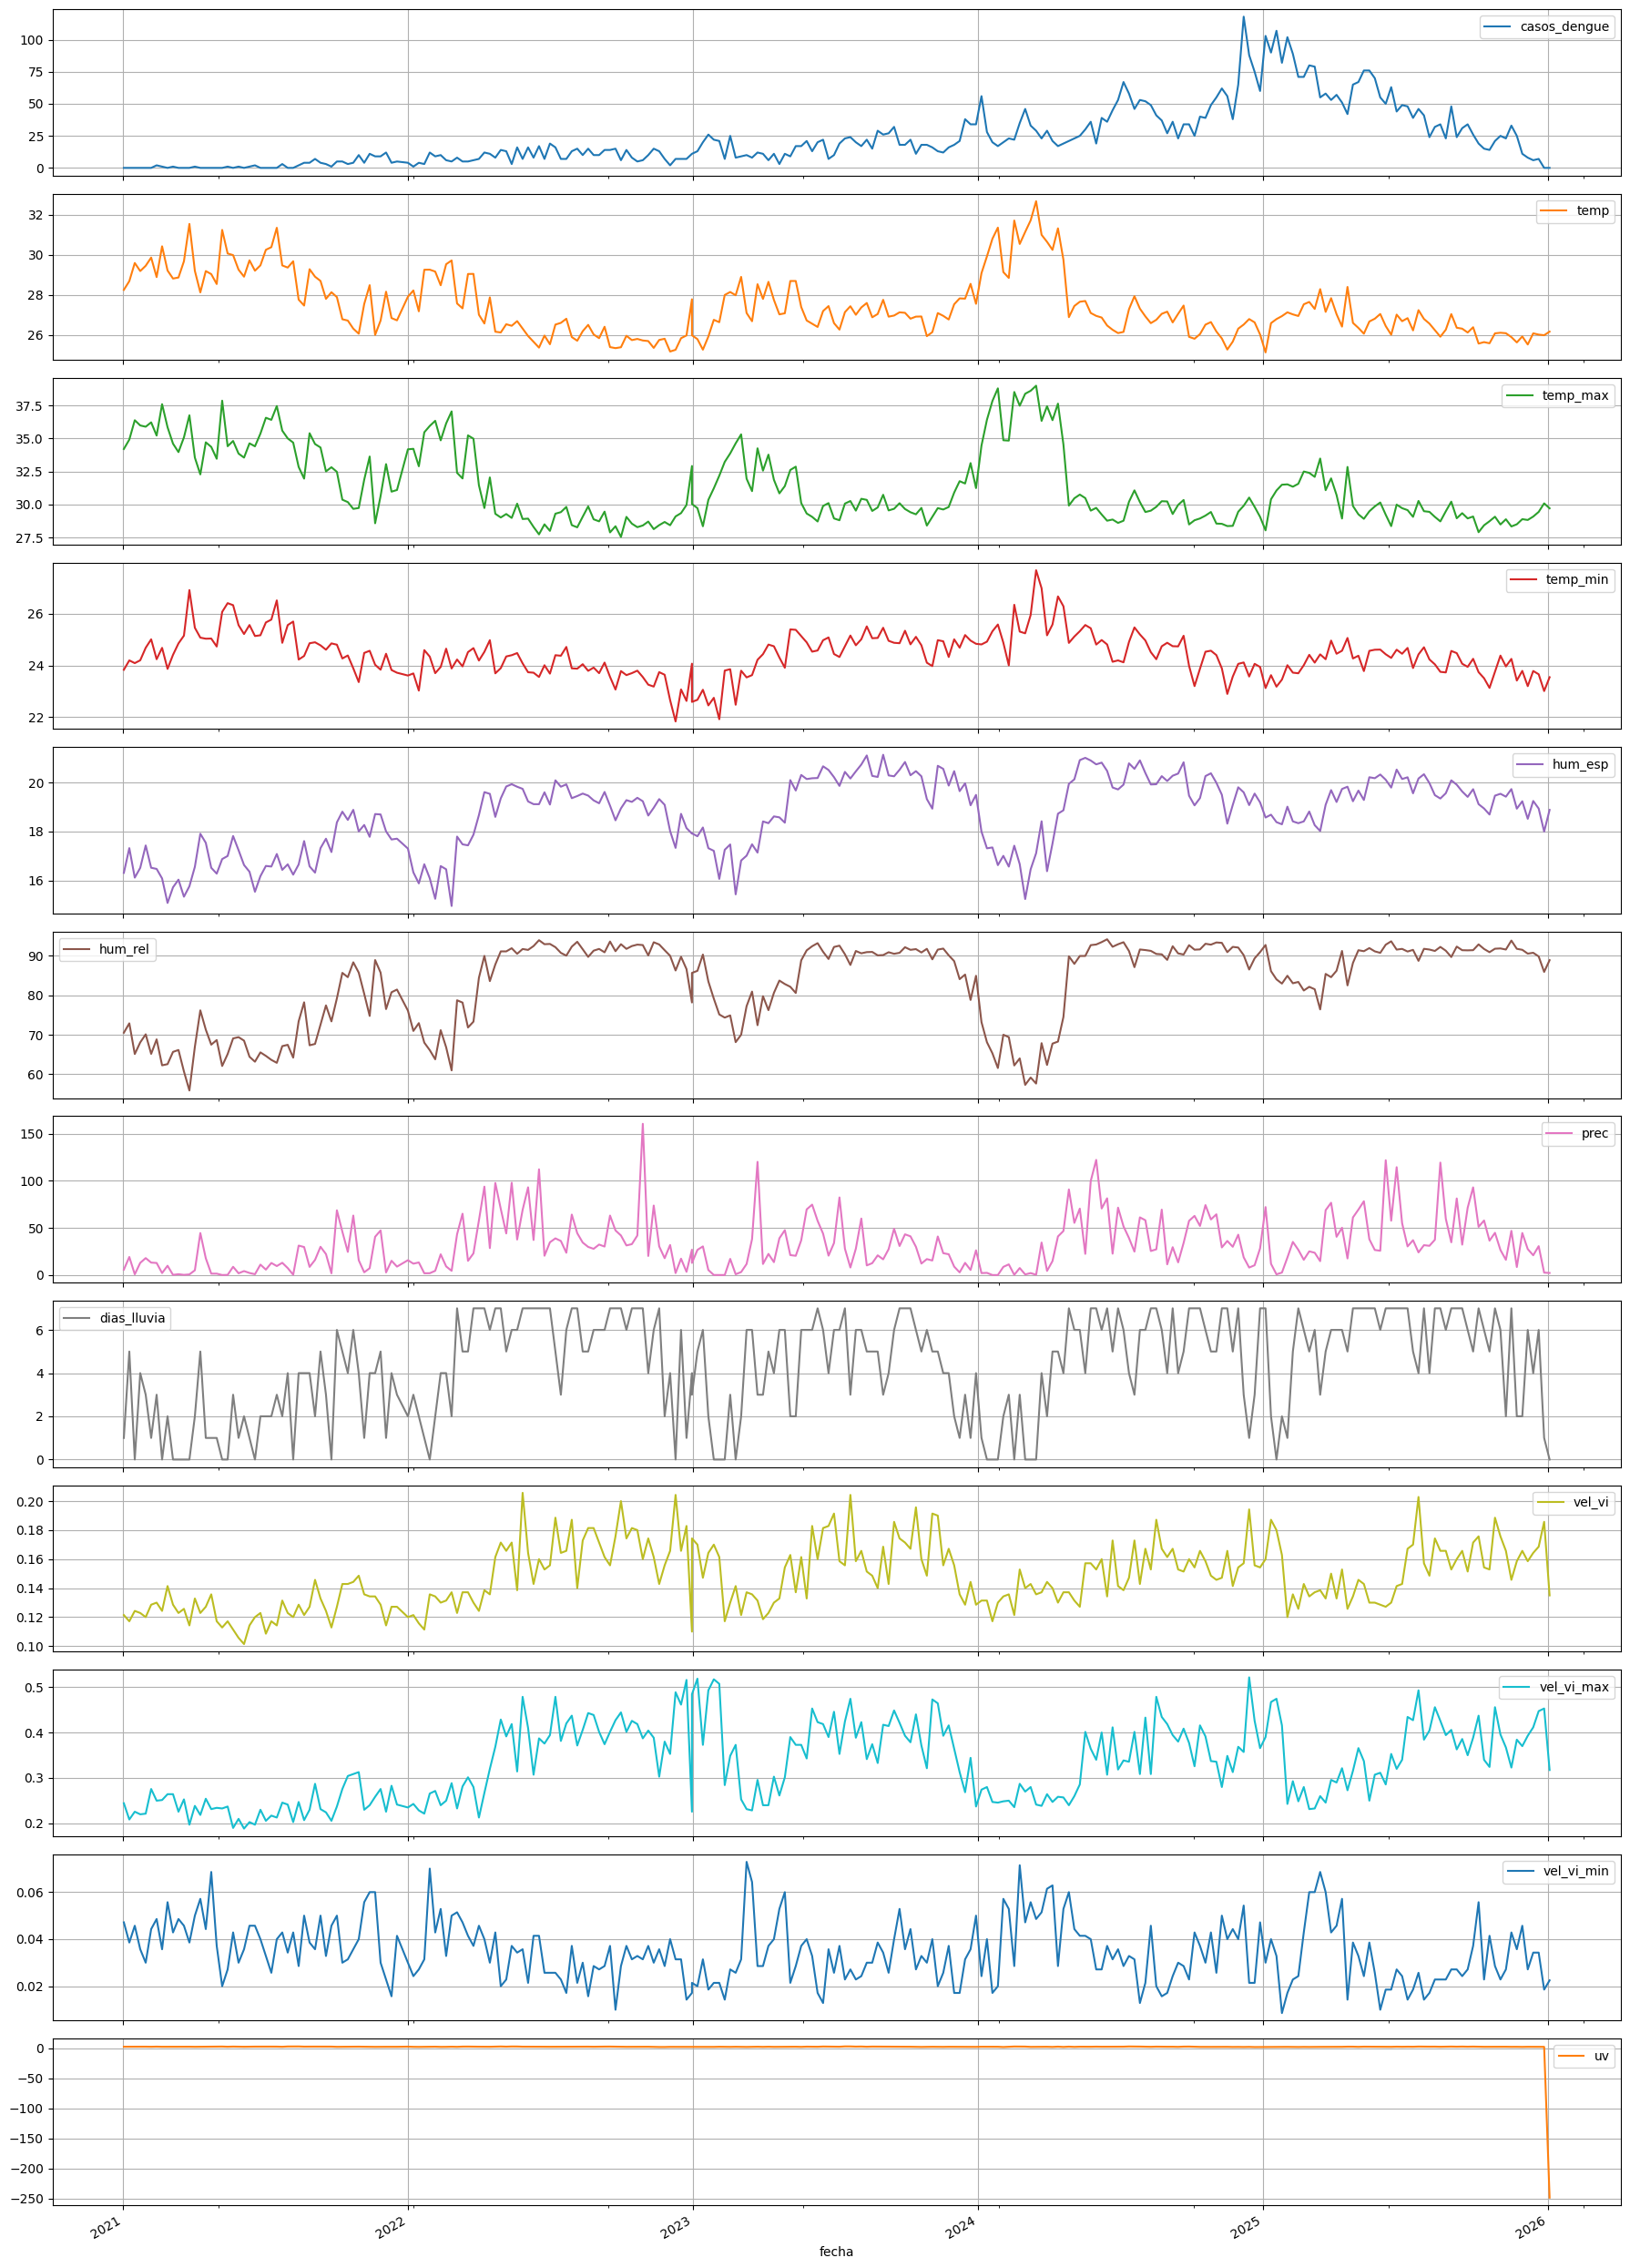

In [8]:
import matplotlib.pyplot as plt

axes = df_fusionado[['casos_dengue', 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'vel_vi_max', 'vel_vi_min', 'uv']].plot(
    subplots=True,
    figsize=(18, 25)
)

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.savefig("series_temporales.png") 
plt.show()


# Interpretación de estas series temporales 

Busca:

* temporadas lluviosas
* ciclos climáticos
* anomalías.

---



# 4. Distribución estadística

Esto ayuda a decidir transformaciones para ARIMA.



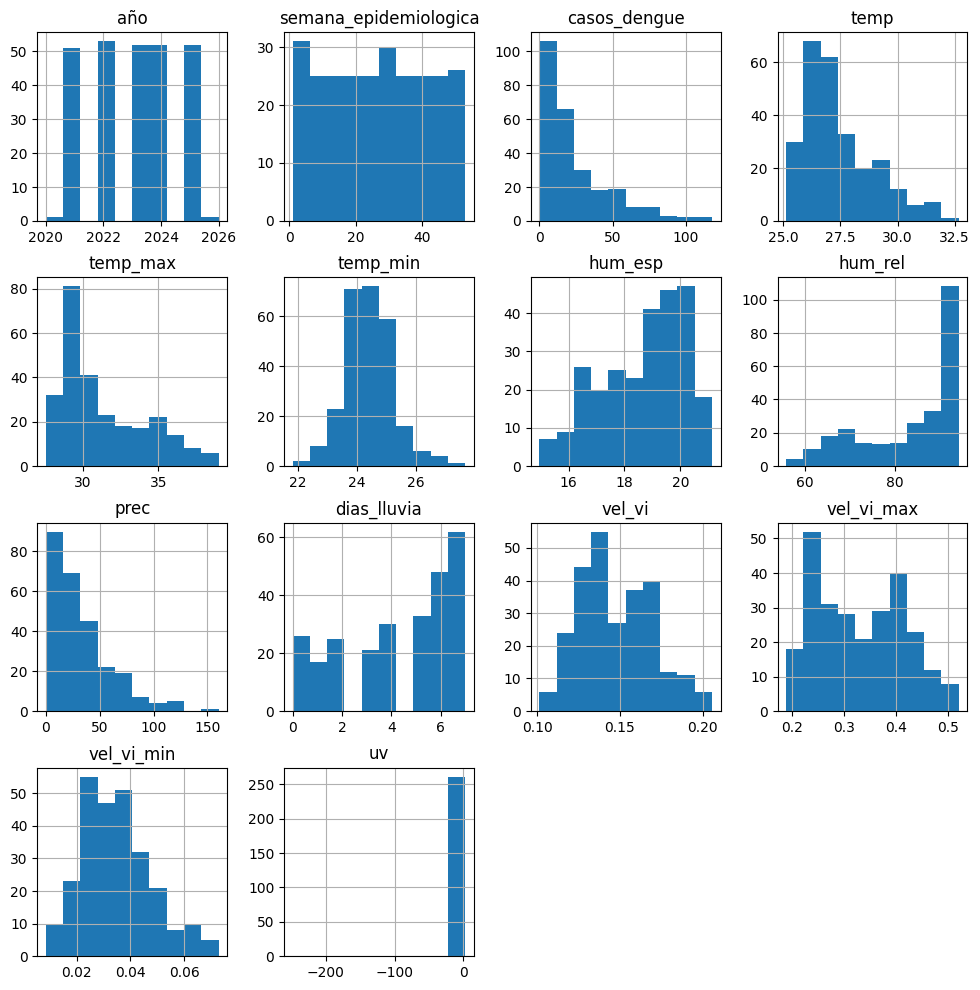

In [9]:
df_fusionado.hist(figsize=(12,12))
plt.savefig("histogramas.png")
plt.show()

# Interpertación de la matriz de histogramas 

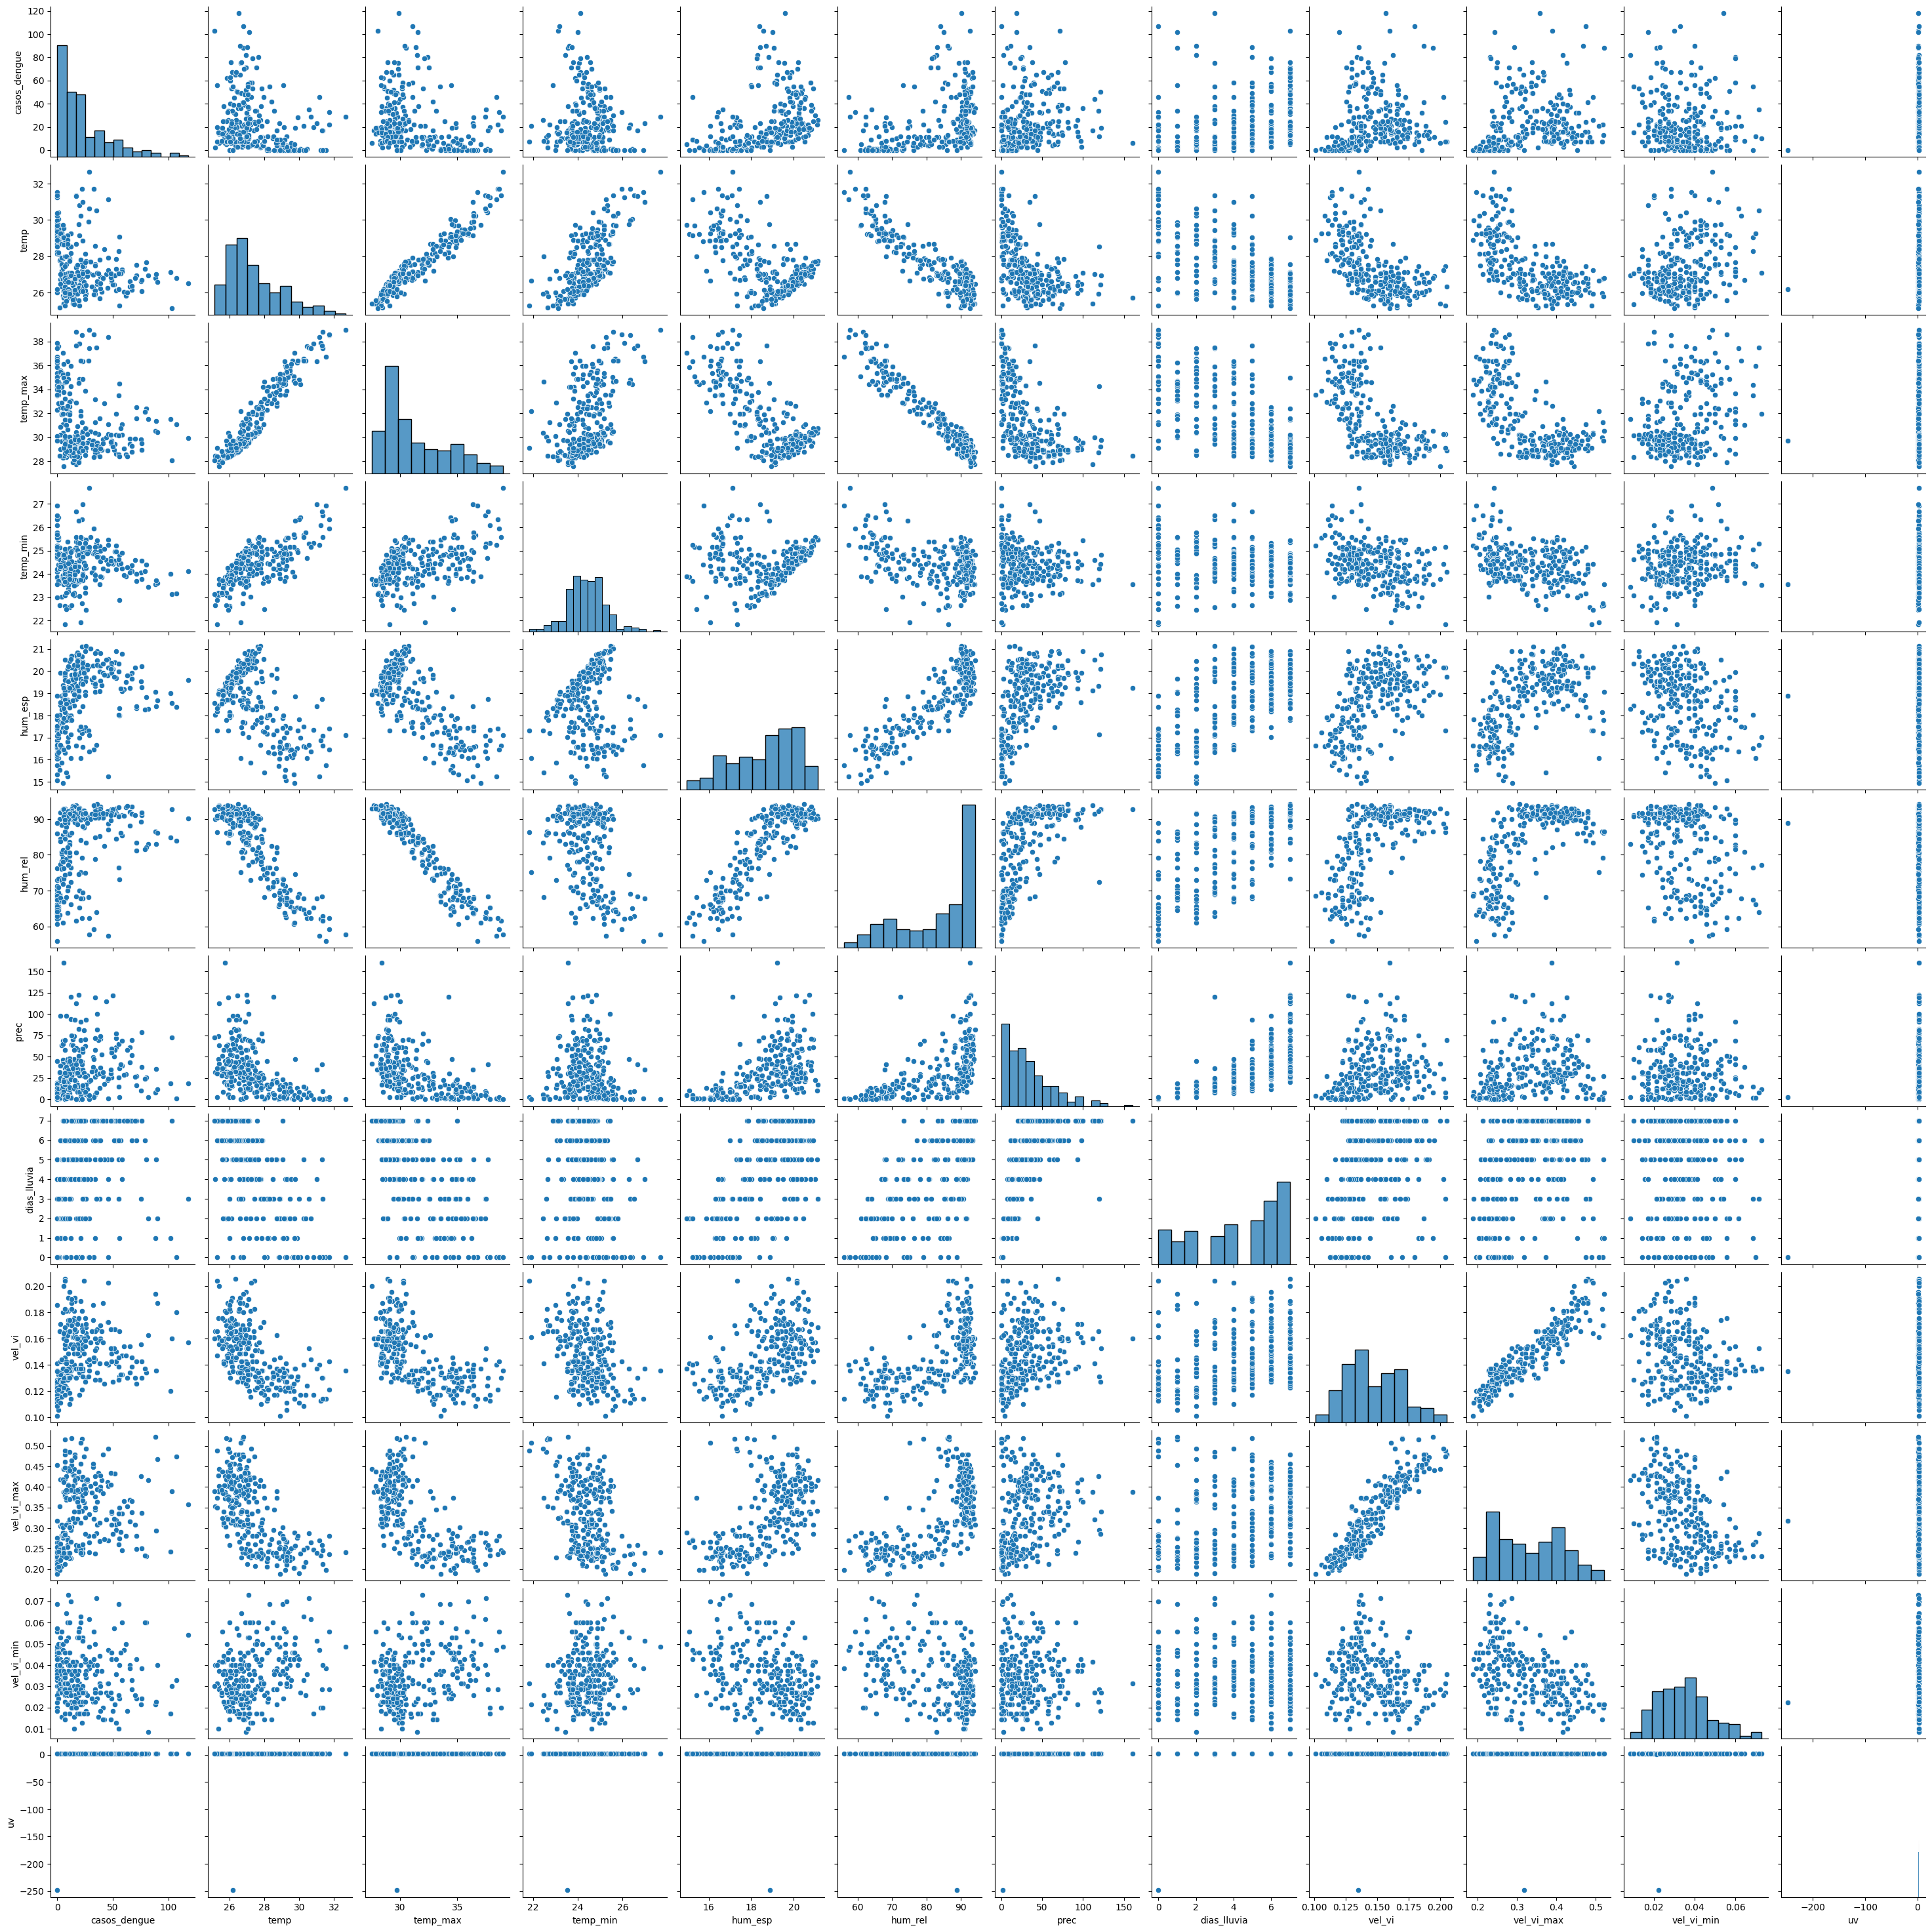

In [10]:
# graficar en una matriz todos los scaterter plots entre las variables numéricas
import seaborn as sns   
sns.pairplot(df_fusionado[['casos_dengue', 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'vel_vi_max', 'vel_vi_min', 'uv']])
plt.savefig("scatter_matrix.png")
plt.show()

# Interpretación de la matriz de diagramas de dispersión. 


Especial atención a:

* `casos_dengue`
* `prec`

Muchas veces requieren **log-transform**.

---



# 5. Correlación simple

Primer vistazo a relaciones clima–dengue.



<Axes: >

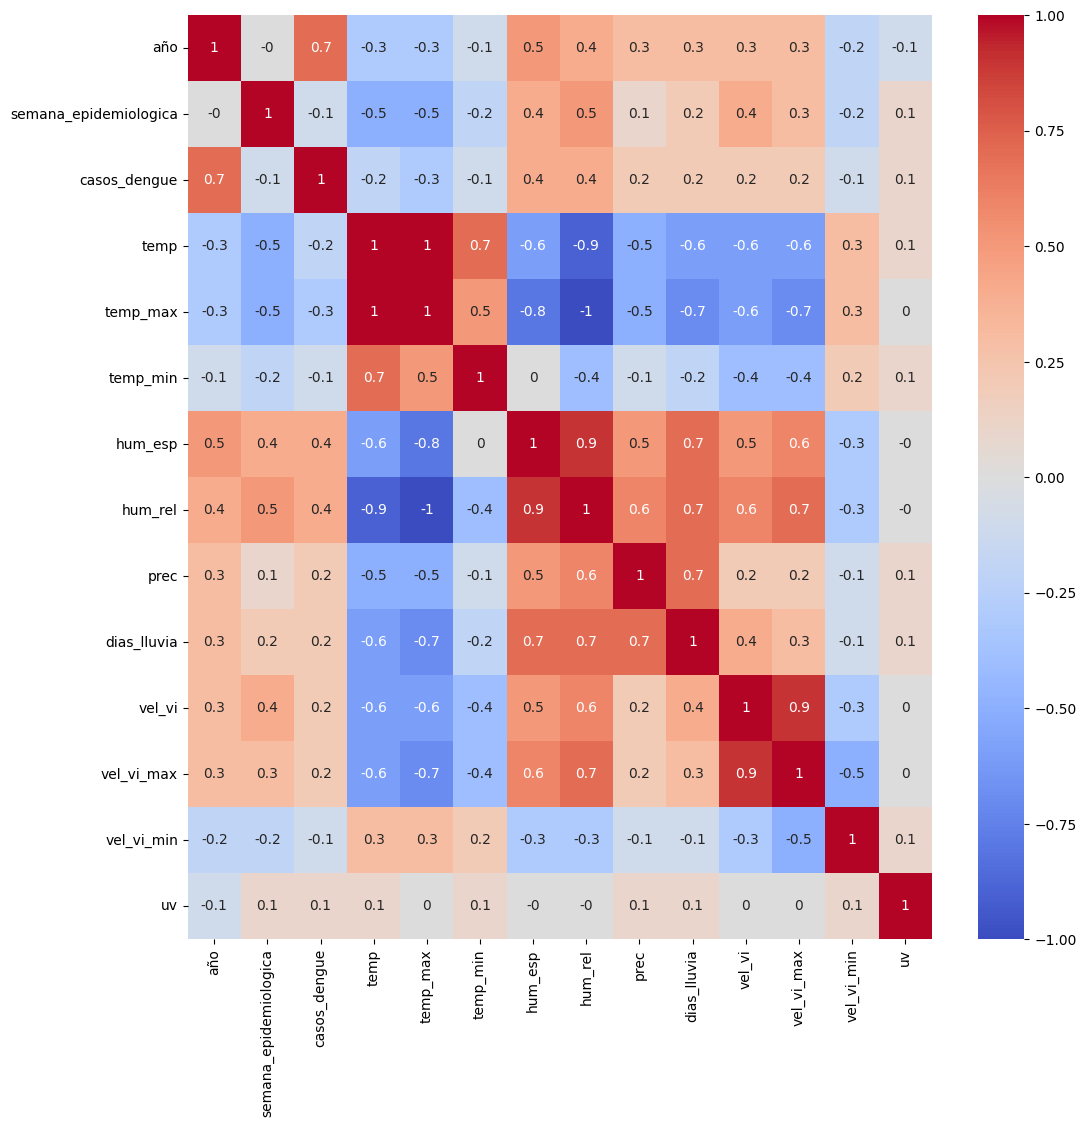

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,12))
sns.heatmap(df_fusionado.corr(method='pearson').round(1), annot=True, cmap="coolwarm")


Observa si:

* lluvia
* humedad
* temperatura

tienen asociación.

---



# 6. Relación visual clima – dengue



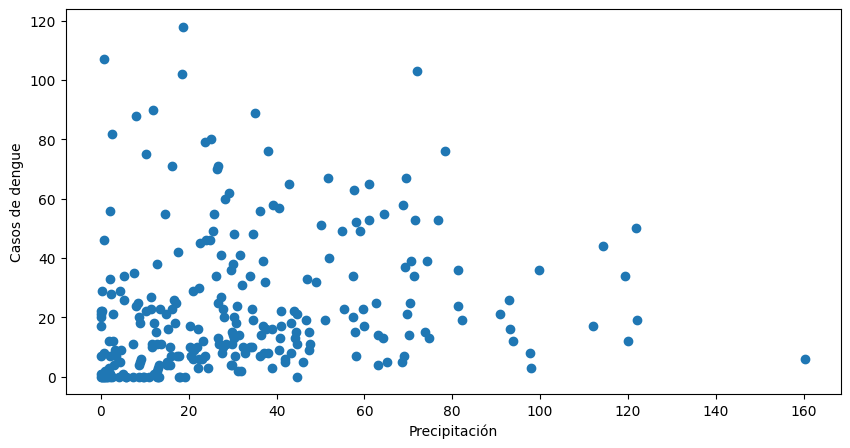

In [12]:
plt.figure(figsize=(10,5))

plt.scatter(df_fusionado["prec"], df_fusionado["casos_dengue"])

plt.xlabel("Precipitación")
plt.ylabel("Casos de dengue")

plt.savefig("scatter_prec_casos.png")
plt.show()


# Interpretación del scatter anterior. 

# 7. Estacionalidad epidemiológica

Muy importante para dengue.



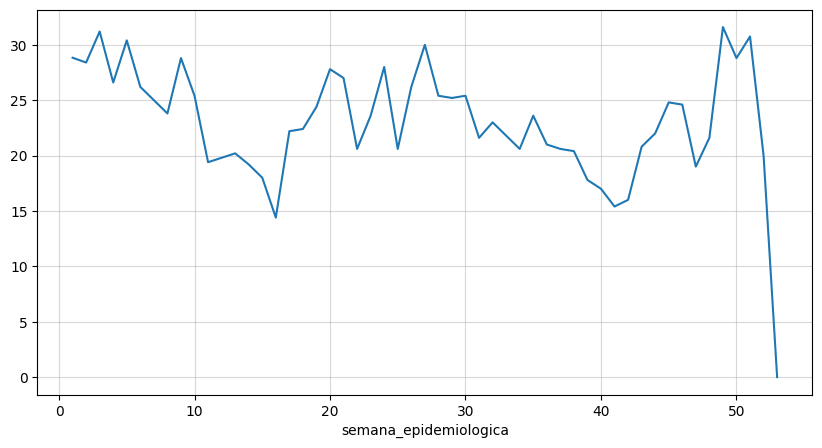

In [13]:
df_fusionado.groupby("semana_epidemiologica")["casos_dengue"].mean().plot(figsize=(10,5))
plt.grid(alpha=0.5) 


Esto muestra:

* semanas de mayor riesgo
* patrón anual.

---



# 8. Análisis de rezagos climáticos (clave para ARIMAX)

El mosquito responde con retraso.


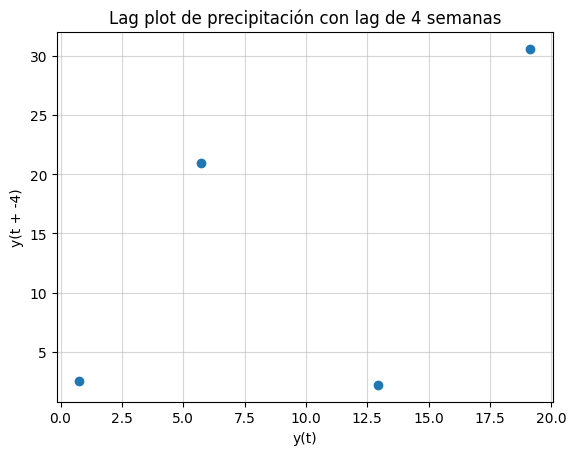

In [ ]:
# Graficar casos de dengue contra cada atributo meteorolóco rezagados 
from pandas.plotting import lag_plot

lag_plot(df_fusionado["prec"], lag=-4)
plt.title("Lag plot de precipitación con lag de 4 semanas")
plt.savefig("lag_plot_prec.png")
plt.grid(alpha=0.5)
plt.show()


También:



In [15]:
df_fusionado.columns 
atributos_meteorologicos = [ 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'vel_vi_max', 'vel_vi_min', 'uv']

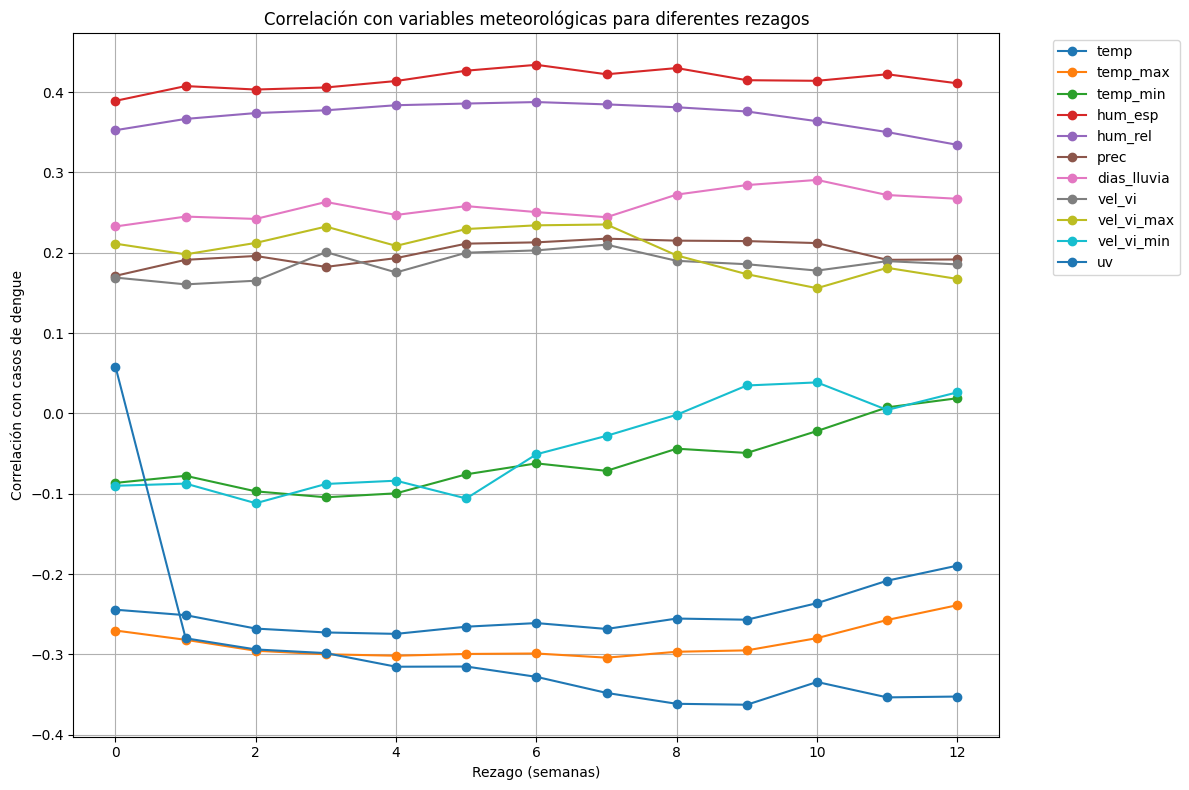

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Variables meteorológicas
variables_meteo = [
    'temp', 'temp_max', 'temp_min',
    'hum_esp', 'hum_rel',
    'prec', 'dias_lluvia',
    'vel_vi', 'vel_vi_max', 'vel_vi_min',
    'uv'
]

# Número máximo de rezagos
max_lag = 12

# DataFrame para guardar resultados
corr_lags = pd.DataFrame(index=range(max_lag + 1), columns=variables_meteo)

# Cálculo de correlaciones
for var in variables_meteo:
    
    for lag in range(max_lag + 1):
        
        corr = df_fusionado['casos_dengue'].corr(
            df_fusionado[var].shift(lag)
        )
        
        corr_lags.loc[lag, var] = corr

# Convertir a float
corr_lags = corr_lags.astype(float)

# ---------- GRAFICO ----------

plt.figure(figsize=(12,8))

for var in variables_meteo:
    plt.plot(corr_lags.index, corr_lags[var], marker='o', label=var)

plt.xlabel('Rezago (semanas)')
plt.ylabel('Correlación con casos de dengue')
plt.title('Correlación con variables meteorológicas para diferentes rezagos')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.savefig("correlacion_rezagos.png")
plt.show()



Muchos estudios encuentran retrasos de:

* 2 semanas
* 4 semanas
* 8 semanas.

---



# 9. Descomposición de la serie

Esto ayuda a ver:

* tendencia
* estacionalidad
* ruido.

```python


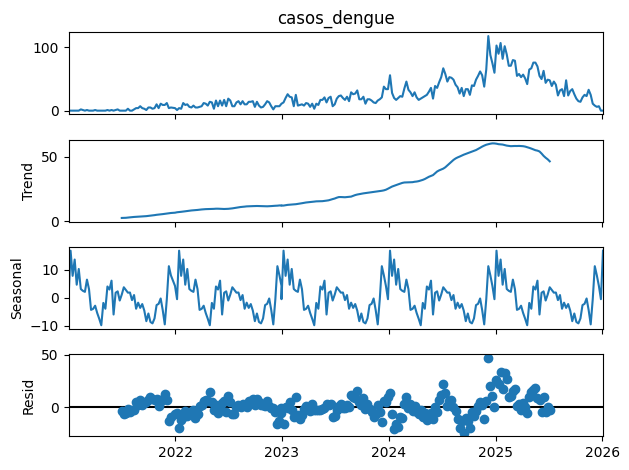

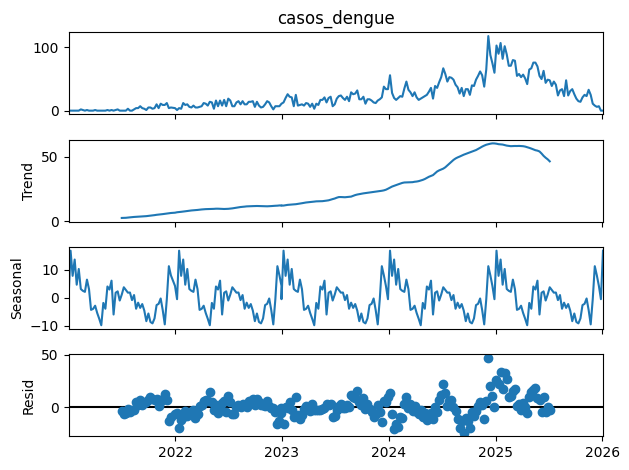

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df_fusionado["casos_dengue"], model="additive", period=52)

decomp.plot()



# 10. Identificación preliminar para ARIMA

Antes de modelar:



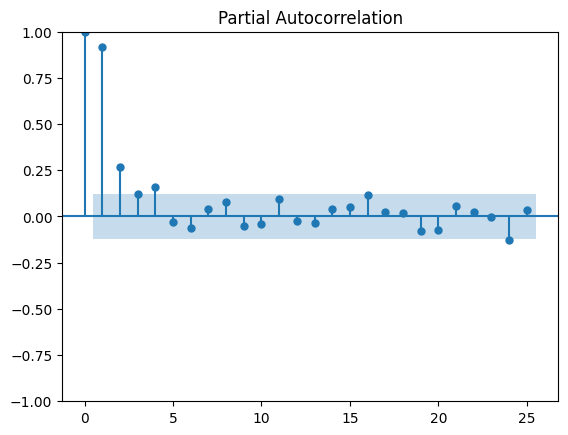

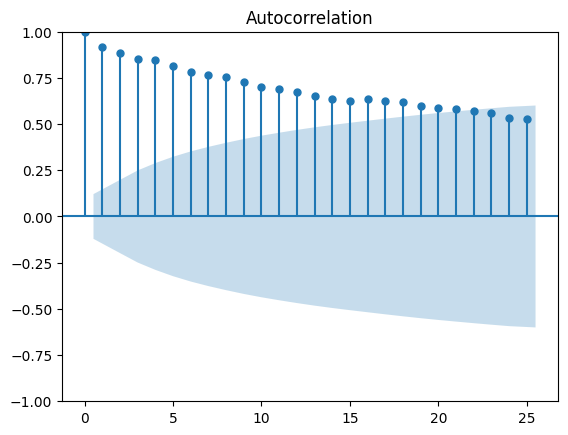

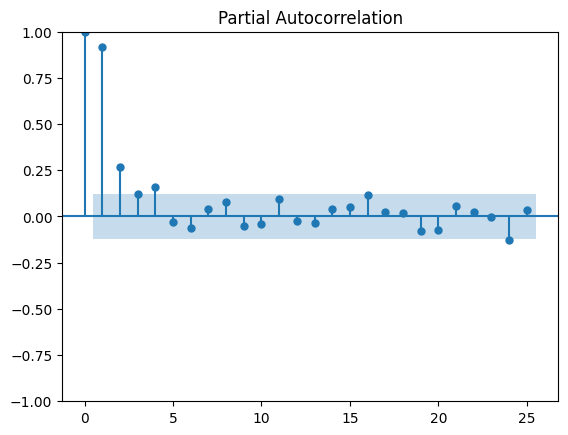

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_fusionado["casos_dengue"])
plot_pacf(df_fusionado["casos_dengue"])



Esto orienta:

* orden AR
* orden MA
* necesidad de diferenciación.

---



# Cómo dejar esta etapa metodológicamente sólida (para un paper)

Puedes estructurar tu notebook así:

```
1_descripcion_datos
2_visualizacion_series
3_estacionalidad
4_relaciones_climaticas
5_lags_climaticos
6_diagnostico_series
```

---



# Algo importante para tu investigación

Muchos artículos fallan porque no revisan **correlación cruzada con rezagos**.

Ese análisis suele revelar cosas como:

```
lluvia  → aumento dengue 3 a 6 semanas después
```

Esto es exactamente lo que necesitas para **ARIMAX epidemiológico**.

---
